# AML Homework 2: GBDT vs MLP on Bank Marketing Dataset

**Task:** Predict whether a customer will subscribe to a term deposit based on demographic and campaign features.

**Dataset:** Bank Marketing (bank-full.csv) — 45,211 records, 16 input features, 1 binary target.

---
## 1. Data Preparation

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load data
df = pd.read_csv('bank+marketing/bank/bank-full.csv', sep=';')
print(f"Shape: {df.shape}")
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [145]:
# Basic info and statistics
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Descriptive Statistics (Numeric) ===")
df.describe()

=== Data Types ===
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

=== Descriptive Statistics (Numeric) ===


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [146]:
# Inspect categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

# Check target distribution
print("\n=== Target Distribution ===")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True))

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

job: <StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

marital: <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

education: <StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str

default: <StringArray>
['no', 'yes']
Length: 2, dtype: str

housing: <StringArray>
['yes', 'no']
Length: 2, dtype: str

loan: <StringArray>
['no', 'yes']
Length: 2, dtype: str

contact: <StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str

month: <StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

poutcome: <StringArray>
['unknown', 'failure', 'other', 'succe

In [147]:
# --- 1.1 Handle missing values & Feature Engineering ---

# 'unknown' values are kept as their own category (may carry signal)

# Drop 'duration' — only known after call ends, not realistic for prediction
df = df.drop(columns=['duration'])
print("Dropped 'duration' column")

# Feature Engineering
# 1) was_previously_contacted: 1 if pdays != -1, else 0
df['was_contacted_before'] = (df['pdays'] != -1).astype(int)

# 2) age_group: bin ages into groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100],
                         labels=['young', 'mid', 'senior', 'elder', 'retired'])

# 3) balance_positive: whether balance is positive
df['balance_positive'] = (df['balance'] > 0).astype(int)

print(f"\nNew features added. Shape: {df.shape}")
print(f"\nwas_contacted_before distribution:\n{df['was_contacted_before'].value_counts()}")
print(f"\nage_group distribution:\n{df['age_group'].value_counts()}")
print(f"\nbalance_positive distribution:\n{df['balance_positive'].value_counts()}")

Dropped 'duration' column

New features added. Shape: (45211, 19)

was_contacted_before distribution:
was_contacted_before
0    36954
1     8257
Name: count, dtype: int64

age_group distribution:
age_group
mid        17687
senior     11239
elder       8067
young       7030
retired     1188
Name: count, dtype: int64

balance_positive distribution:
balance_positive
1    37931
0     7280
Name: count, dtype: int64


In [148]:
# --- 1.2 Encode Categoricals, Split Data, Scale for MLP ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode target: yes=1, no=0 (handles both string and already-encoded int)
if df['y'].dtype == object or df['y'].dtype.name == 'str':
    df['y'] = (df['y'] == 'yes').astype(int)

# One-hot encode all categorical columns (drop_first to avoid multicollinearity)
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome', 'age_group']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns ({len(df_encoded.columns)}):\n{list(df_encoded.columns)}")

# Separate features and target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Split: 70% train, 15% validation, 15% test (stratified to preserve class balance)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train target rate: {y_train.mean():.4f}")
print(f"Val   target rate: {y_val.mean():.4f}")
print(f"Test  target rate: {y_test.mean():.4f}")

# Scale features for MLP (fit on training set ONLY — no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaler fit on training set only. Scaled arrays ready for MLP.")

Shape after encoding: (45211, 48)
Columns (48):
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'y', 'was_contacted_before', 'balance_positive', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'age_group_mid', 'age_group_senior', 'age_group_elder', 'age_group_retired']

Train: 31647 | Val: 6782 | Test: 6782
Train target rate: 0.1170
Val   target rate: 0.1171
Test  target rate: 0.1169

Scaler fit on training set only. Scaled arrays ready for MLP.


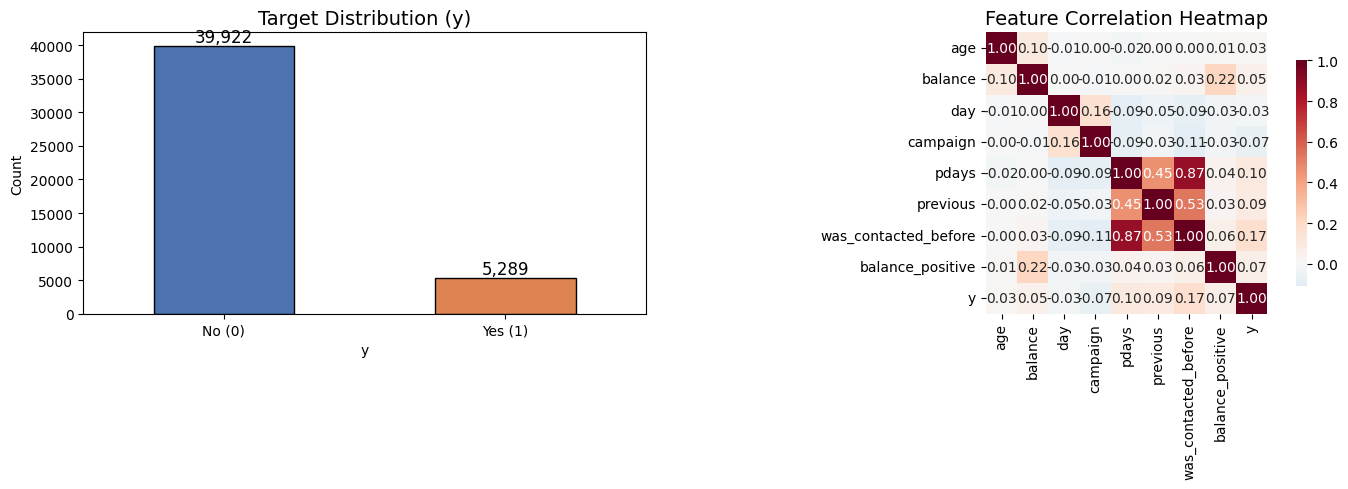

Saved: fig_data_preparation.png


In [149]:
# --- 1.3 Data Preparation Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Target class distribution
y.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Target Distribution (y)', fontsize=14)
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# 2) Correlation heatmap of original numeric features with target
numeric_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous',
                'was_contacted_before', 'balance_positive']
corr_df = df_encoded[numeric_cols + ['y']].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.savefig('fig_data_preparation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_data_preparation.png")

---
## 2. Gradient Boosted Decision Trees (GBDT)

In [150]:
# --- 2.1 Baseline XGBoost with Early Stopping ---
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score
import time

# Baseline model with reasonable defaults
xgb_baseline = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=500,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle class imbalance
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False
)

# Train with eval_set for monitoring + early stopping
start_time = time.time()
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
xgb_train_time = time.time() - start_time

# Predictions on validation set
y_val_pred = xgb_baseline.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print(f"Baseline XGBoost (500 trees, lr=0.1, depth=5)")
print(f"Training time: {xgb_train_time:.2f}s")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation F1-score: {val_f1:.4f}")
print(f"Trees used: {xgb_baseline.best_iteration + 1 if hasattr(xgb_baseline, 'best_iteration') and xgb_baseline.best_iteration else 500}")

Baseline XGBoost (500 trees, lr=0.1, depth=5)
Training time: 0.67s
Validation Accuracy: 0.8300
Validation F1-score: 0.4496
Trees used: 500


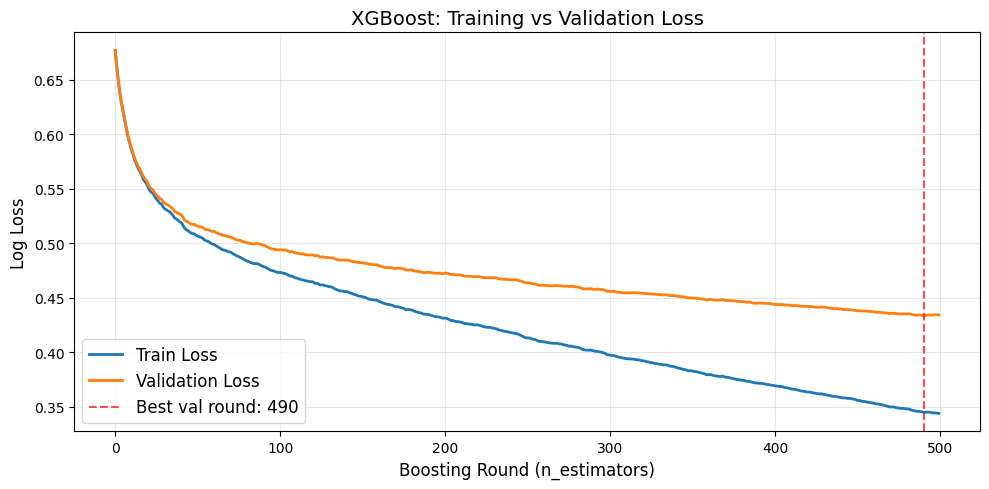

Best validation loss at round 490: 0.4337
Train loss at same round: 0.3449

Gap between train and val loss suggests mild/no overfitting.


In [151]:
# --- 2.2 Training vs Validation Loss Curve ---
results = xgb_baseline.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, label='Train Loss', linewidth=2)
ax.plot(val_loss, label='Validation Loss', linewidth=2)
ax.set_xlabel('Boosting Round (n_estimators)', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_title('XGBoost: Training vs Validation Loss', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Mark the point where val loss is minimum
best_round = np.argmin(val_loss)
ax.axvline(x=best_round, color='red', linestyle='--', alpha=0.7,
           label=f'Best val round: {best_round}')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('fig_xgb_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best validation loss at round {best_round}: {val_loss[best_round]:.4f}")
print(f"Train loss at same round: {train_loss[best_round]:.4f}")
print(f"\nGap between train and val loss suggests {'overfitting' if val_loss[-1] > val_loss[best_round] + 0.01 else 'mild/no overfitting'}.")

lr=0.01: Val Accuracy=0.8061, Val F1=0.4368, Best val loss=0.5181 at round 499
lr=0.1: Val Accuracy=0.8300, Val F1=0.4496, Best val loss=0.4337 at round 490
lr=0.3: Val Accuracy=0.8418, Val F1=0.4178, Best val loss=0.4075 at round 490


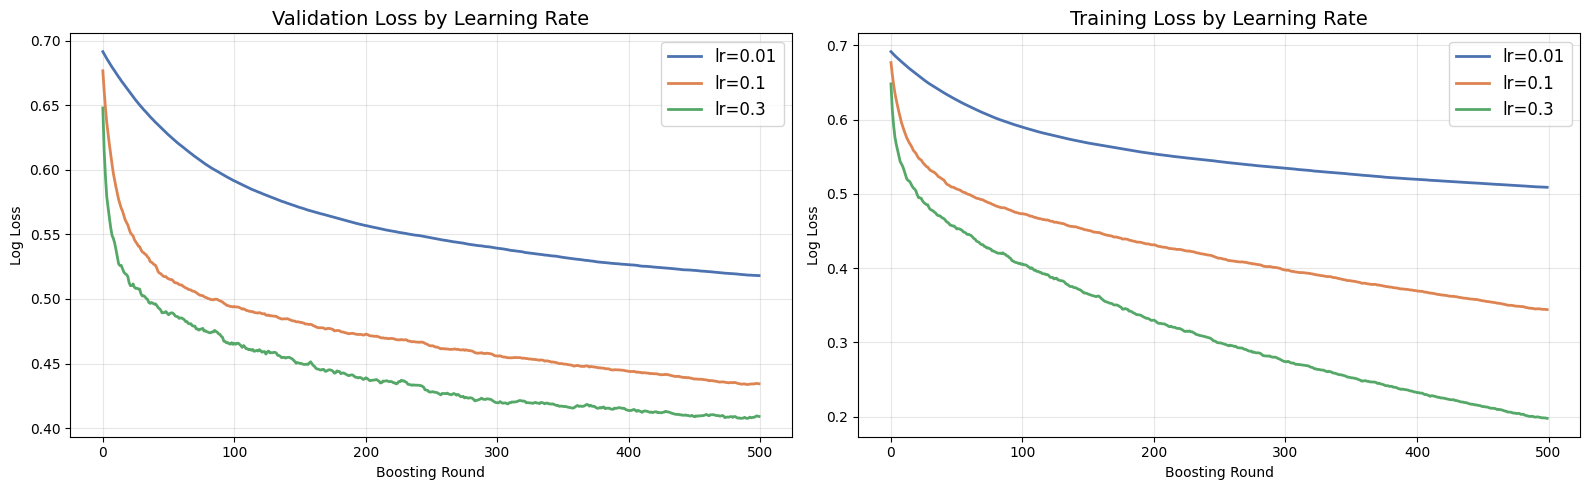

In [152]:
# --- 2.3 Effect of Learning Rate ---
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

for lr in learning_rates:
    model = xgb.XGBClassifier(
        learning_rate=lr,
        n_estimators=500,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        use_label_encoder=False
    )
    model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_val, y_val)],
              verbose=False)
    
    y_pred = model.predict(X_val)
    res = model.evals_result()
    lr_results[lr] = {
        'model': model,
        'train_loss': res['validation_0']['logloss'],
        'val_loss': res['validation_1']['logloss'],
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred)
    }
    print(f"lr={lr}: Val Accuracy={lr_results[lr]['accuracy']:.4f}, Val F1={lr_results[lr]['f1']:.4f}, "
          f"Best val loss={min(lr_results[lr]['val_loss']):.4f} at round {np.argmin(lr_results[lr]['val_loss'])}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for (lr, res), color in zip(lr_results.items(), colors):
    axes[0].plot(res['val_loss'], label=f'lr={lr}', linewidth=2, color=color)
    axes[1].plot(res['train_loss'], label=f'lr={lr}', linewidth=2, color=color)

axes[0].set_title('Validation Loss by Learning Rate', fontsize=14)
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Log Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Training Loss by Learning Rate', fontsize=14)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Log Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_xgb_learning_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [153]:
# --- 2.4 Hyperparameter Tuning with RandomizedSearchCV ---
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        use_label_encoder=False
    ),
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print(f"\nBest F1 (CV): {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best F1 (CV): 0.4461
Best params: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05}


=== Tuned XGBoost — Validation Performance ===
Training time: 0.32s
              precision    recall  f1-score   support

          No       0.95      0.86      0.90      5988
         Yes       0.37      0.63      0.47       794

    accuracy                           0.83      6782
   macro avg       0.66      0.75      0.68      6782
weighted avg       0.88      0.83      0.85      6782



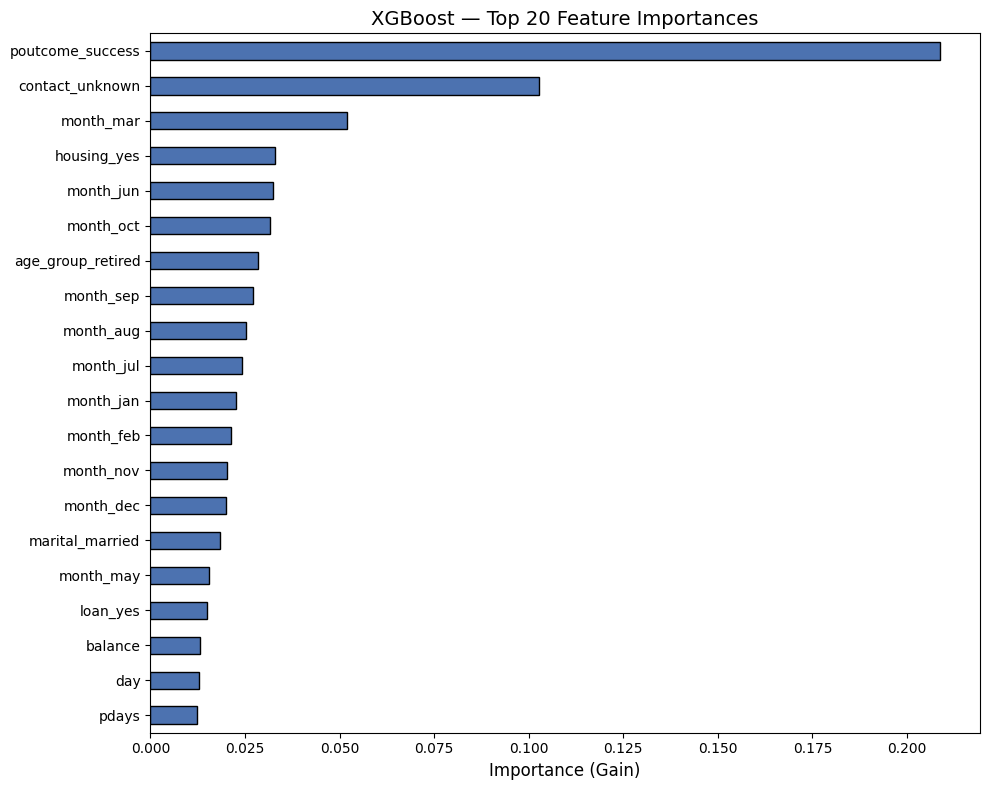

In [154]:
# --- 2.5 Final GBDT Model + Feature Importance ---
from sklearn.metrics import classification_report

# Retrain best model with eval_set for loss tracking
best_params = xgb_search.best_params_
xgb_final = xgb.XGBClassifier(
    **best_params,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False
)

start_time = time.time()
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
xgb_final_train_time = time.time() - start_time

y_val_pred_xgb = xgb_final.predict(X_val)
print("=== Tuned XGBoost — Validation Performance ===")
print(f"Training time: {xgb_final_train_time:.2f}s")
print(classification_report(y_val, y_val_pred_xgb, target_names=['No', 'Yes']))

# Feature importance plot (top 20)
importances = pd.Series(xgb_final.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='black')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14)
ax.set_xlabel('Importance (Gain)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Multi-Layer Perceptron (MLP)

=== Baseline MLP (128,) — Validation Performance ===
Training time: 1.78s
Converged in 34 iterations
              precision    recall  f1-score   support

          No       0.91      0.98      0.94      5988
         Yes       0.64      0.24      0.34       794

    accuracy                           0.90      6782
   macro avg       0.77      0.61      0.64      6782
weighted avg       0.88      0.90      0.87      6782



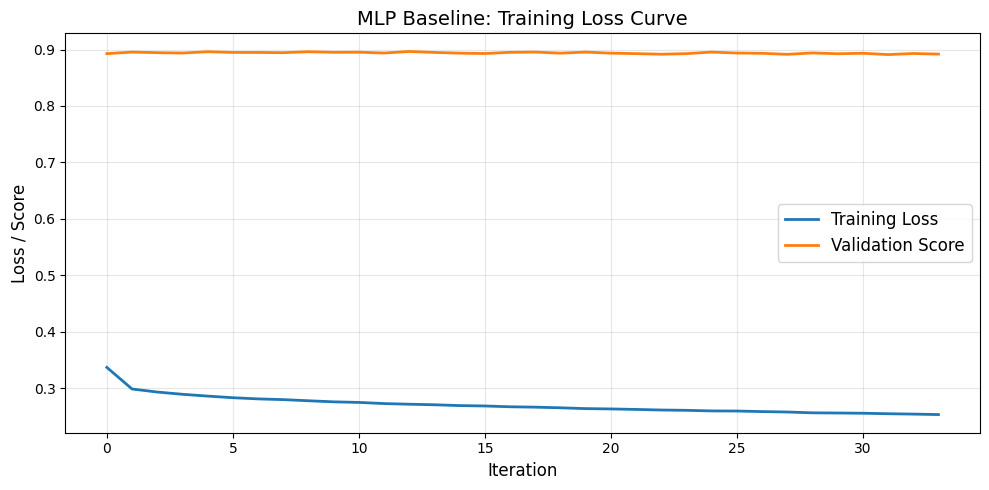

In [155]:
# --- 3.1 Baseline MLP ---
from sklearn.neural_network import MLPClassifier

# Baseline: single hidden layer with 128 neurons
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    verbose=False
)

start_time = time.time()
mlp_baseline.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time

y_val_pred_mlp_base = mlp_baseline.predict(X_val_scaled)
print("=== Baseline MLP (128,) — Validation Performance ===")
print(f"Training time: {mlp_train_time:.2f}s")
print(f"Converged in {mlp_baseline.n_iter_} iterations")
print(classification_report(y_val, y_val_pred_mlp_base, target_names=['No', 'Yes']))

# Training loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_baseline.loss_curve_, label='Training Loss', linewidth=2)
if hasattr(mlp_baseline, 'validation_scores_') and mlp_baseline.validation_scores_:
    ax.plot(mlp_baseline.validation_scores_, label='Validation Score', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss / Score', fontsize=12)
ax.set_title('MLP Baseline: Training Loss Curve', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Before oversampling: 31647 samples (pos rate: 0.117)
After oversampling:  55890 samples (pos rate: 0.500)

=== MLP with Oversampled Data — Validation ===
Converged in 235 iterations
              precision    recall  f1-score   support

          No       0.92      0.84      0.88      5988
         Yes       0.28      0.48      0.36       794

    accuracy                           0.80      6782
   macro avg       0.60      0.66      0.62      6782
weighted avg       0.85      0.80      0.82      6782



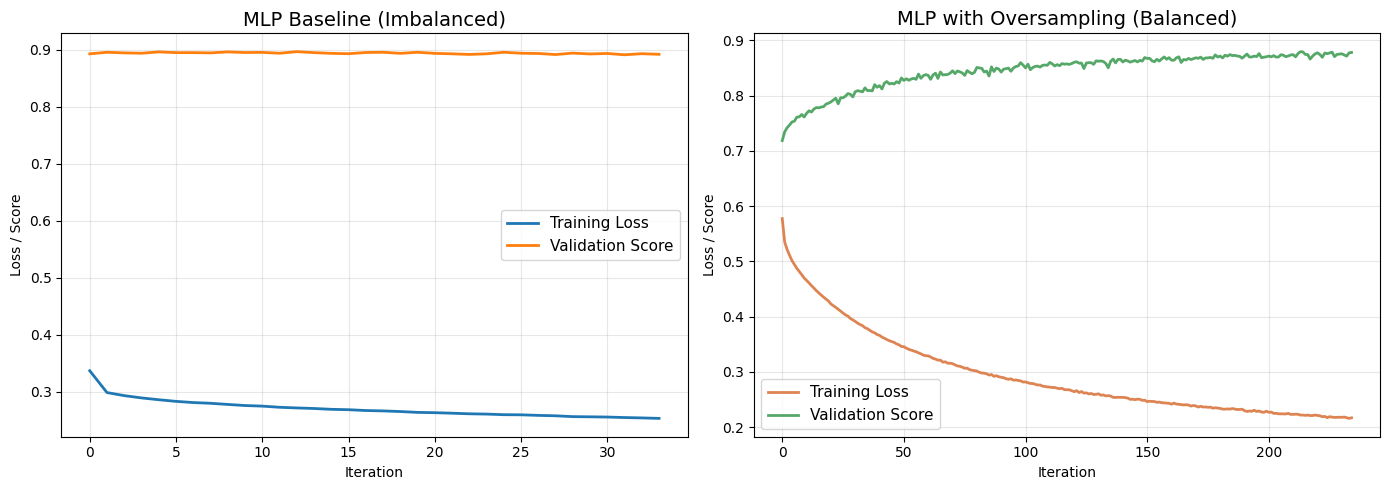

In [156]:
# --- 3.2 Handle class imbalance for MLP via oversampling ---
# sklearn MLPClassifier has no class_weight parameter, so we oversample the minority class
from sklearn.utils import resample

# Separate majority and minority in training set
X_train_df = pd.DataFrame(X_train_scaled, index=y_train.index)
majority = X_train_df[y_train == 0]
minority = X_train_df[y_train == 1]
y_maj = y_train[y_train == 0]
y_min = y_train[y_train == 1]

# Oversample minority to match majority
minority_up, y_min_up = resample(minority, y_min,
                                  replace=True,
                                  n_samples=len(majority),
                                  random_state=RANDOM_STATE)

X_train_bal = np.vstack([majority.values, minority_up.values])
y_train_bal = np.concatenate([y_maj.values, y_min_up.values])

# Shuffle
shuffle_idx = np.random.RandomState(RANDOM_STATE).permutation(len(y_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"Before oversampling: {len(y_train)} samples (pos rate: {y_train.mean():.3f})")
print(f"After oversampling:  {len(y_train_bal)} samples (pos rate: {y_train_bal.mean():.3f})")

# Retrain baseline with balanced data
mlp_bal = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    verbose=False
)
mlp_bal.fit(X_train_bal, y_train_bal)

y_val_pred_bal = mlp_bal.predict(X_val_scaled)
print(f"\n=== MLP with Oversampled Data — Validation ===")
print(f"Converged in {mlp_bal.n_iter_} iterations")
print(classification_report(y_val, y_val_pred_bal, target_names=['No', 'Yes']))

# Loss curve comparison: baseline vs balanced
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_baseline.loss_curve_, label='Training Loss', linewidth=2)
if mlp_baseline.validation_scores_:
    axes[0].plot(mlp_baseline.validation_scores_, label='Validation Score', linewidth=2)
axes[0].set_title('MLP Baseline (Imbalanced)', fontsize=14)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss / Score')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_bal.loss_curve_, label='Training Loss', linewidth=2, color='#DD8452')
if mlp_bal.validation_scores_:
    axes[1].plot(mlp_bal.validation_scores_, label='Validation Score', linewidth=2, color='#55A868')
axes[1].set_title('MLP with Oversampling (Balanced)', fontsize=14)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss / Score')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_mlp_loss_balanced_vs_imbalanced.png', dpi=150, bbox_inches='tight')
plt.show()

(64,)                 Acc=0.7737  F1=0.3596  Iters=142
(128,)                Acc=0.7974  F1=0.3567  Iters=235
(128, 64)             Acc=0.8332  F1=0.3585  Iters=176
(256, 128, 64)        Acc=0.8511  F1=0.3390  Iters=147


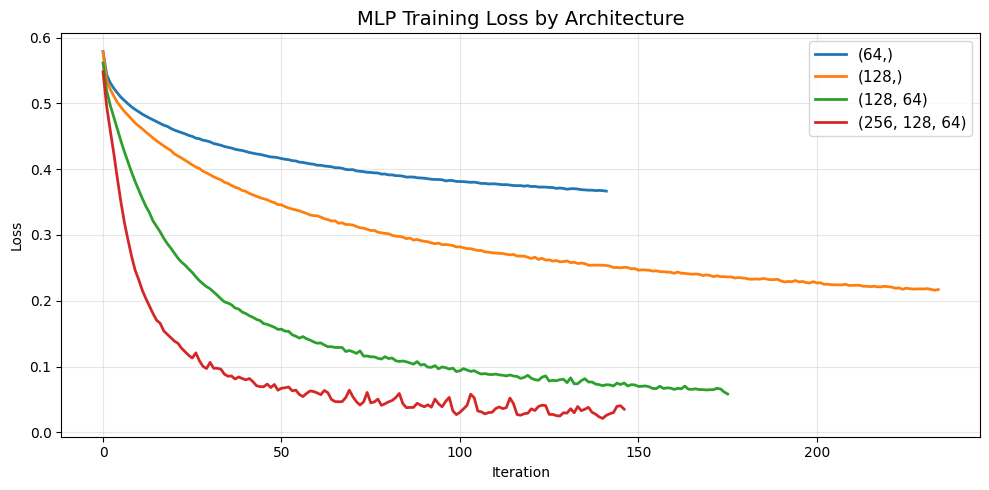

In [157]:
# --- 3.3 Effect of Network Depth/Width on Validation Performance ---
architectures = {
    '(64,)': (64,),
    '(128,)': (128,),
    '(128, 64)': (128, 64),
    '(256, 128, 64)': (256, 128, 64),
}

arch_results = {}
for name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        verbose=False
    )
    mlp.fit(X_train_bal, y_train_bal)
    y_pred = mlp.predict(X_val_scaled)
    
    arch_results[name] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'iters': mlp.n_iter_,
        'loss_curve': mlp.loss_curve_
    }
    print(f"{name:20s}  Acc={arch_results[name]['accuracy']:.4f}  "
          f"F1={arch_results[name]['f1']:.4f}  Iters={mlp.n_iter_}")

# Plot loss curves for each architecture
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in arch_results.items():
    ax.plot(res['loss_curve'], label=name, linewidth=2)
ax.set_title('MLP Training Loss by Architecture', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mlp_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

relu, lr=0.001        Acc=0.7974  F1=0.3567  Iters=235
relu, lr=0.01         Acc=0.7712  F1=0.3310  Iters=87
relu, lr=0.1          Acc=0.7993  F1=0.4116  Iters=49
tanh, lr=0.001        Acc=0.8148  F1=0.3305  Iters=300
tanh, lr=0.01         Acc=0.8158  F1=0.3149  Iters=113


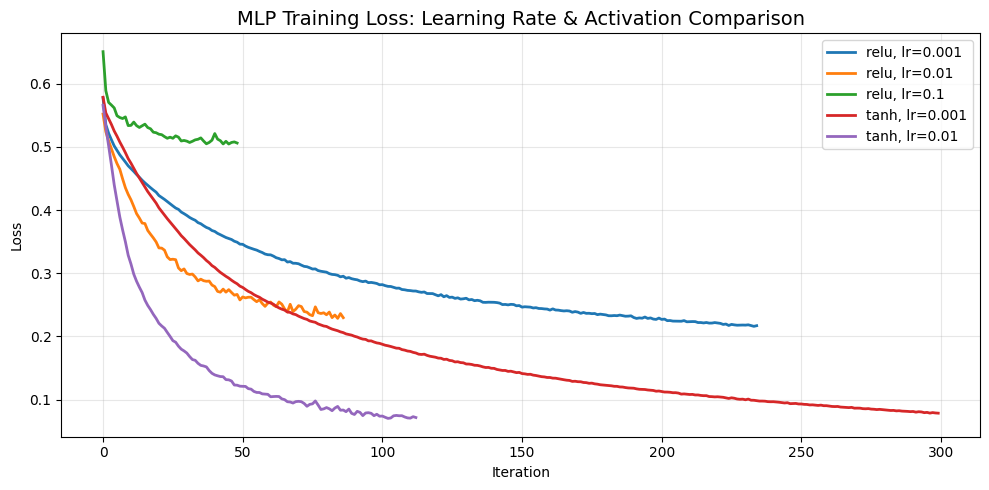

In [158]:
# --- 3.4 Effect of Learning Rate and Activation Function ---
configs = {
    'relu, lr=0.001': {'activation': 'relu', 'learning_rate_init': 0.001},
    'relu, lr=0.01':  {'activation': 'relu', 'learning_rate_init': 0.01},
    'relu, lr=0.1':   {'activation': 'relu', 'learning_rate_init': 0.1},
    'tanh, lr=0.001': {'activation': 'tanh', 'learning_rate_init': 0.001},
    'tanh, lr=0.01':  {'activation': 'tanh', 'learning_rate_init': 0.01},
}

lr_act_results = {}
for name, params in configs.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=(128,),
        **params,
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        verbose=False
    )
    mlp.fit(X_train_bal, y_train_bal)
    y_pred = mlp.predict(X_val_scaled)
    
    lr_act_results[name] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'iters': mlp.n_iter_,
        'loss_curve': mlp.loss_curve_
    }
    print(f"{name:20s}  Acc={lr_act_results[name]['accuracy']:.4f}  "
          f"F1={lr_act_results[name]['f1']:.4f}  Iters={mlp.n_iter_}")

# Plot loss curves
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in lr_act_results.items():
    ax.plot(res['loss_curve'], label=name, linewidth=2)
ax.set_title('MLP Training Loss: Learning Rate & Activation Comparison', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mlp_lr_activation.png', dpi=150, bbox_inches='tight')
plt.show()

In [159]:
# --- 3.5 Hyperparameter Tuning with RandomizedSearchCV ---
from sklearn.model_selection import RandomizedSearchCV

mlp_param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (128, 64), (256, 128), (64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.05, 0.1],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
}

mlp_search = RandomizedSearchCV(
    MLPClassifier(
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
    ),
    param_distributions=mlp_param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

# Use oversampled balanced data for tuning
mlp_search.fit(X_train_bal, y_train_bal)

print(f"\nBest F1 (CV): {mlp_search.best_score_:.4f}")
print(f"Best params: {mlp_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best F1 (CV): 0.9278
Best params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'activation': 'tanh'}


=== Tuned MLP — Validation Performance ===
Best params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'activation': 'tanh'}
Training time: 32.28s
Converged in 188 iterations
              precision    recall  f1-score   support

          No       0.91      0.89      0.90      5988
         Yes       0.31      0.35      0.33       794

    accuracy                           0.83      6782
   macro avg       0.61      0.62      0.62      6782
weighted avg       0.84      0.83      0.84      6782



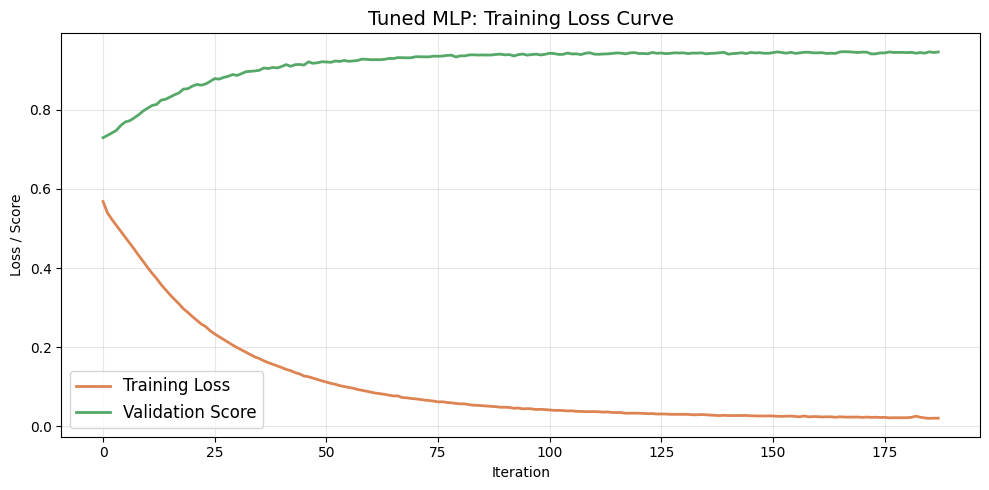

In [160]:
# --- 3.6 Final MLP Model ---
best_mlp_params = mlp_search.best_params_
mlp_final = MLPClassifier(
    **best_mlp_params,
    max_iter=300,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    verbose=False
)

start_time = time.time()
mlp_final.fit(X_train_bal, y_train_bal)
mlp_final_train_time = time.time() - start_time

y_val_pred_mlp = mlp_final.predict(X_val_scaled)
print("=== Tuned MLP — Validation Performance ===")
print(f"Best params: {best_mlp_params}")
print(f"Training time: {mlp_final_train_time:.2f}s")
print(f"Converged in {mlp_final.n_iter_} iterations")
print(classification_report(y_val, y_val_pred_mlp, target_names=['No', 'Yes']))

# Final loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_final.loss_curve_, label='Training Loss', linewidth=2, color='#DD8452')
if mlp_final.validation_scores_:
    ax.plot(mlp_final.validation_scores_, label='Validation Score', linewidth=2, color='#55A868')
ax.set_title('Tuned MLP: Training Loss Curve', fontsize=14)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss / Score')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mlp_final_loss.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. GBDT vs MLP Comparison

In [162]:
# --- 4.1 Test Set Evaluation & Comparison Table ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, average_precision_score, precision_recall_curve)

# Predictions on TEST set (held out until now)
y_test_pred_xgb = xgb_final.predict(X_test)
y_test_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]

y_test_pred_mlp = mlp_final.predict(X_test_scaled)
y_test_prob_mlp = mlp_final.predict_proba(X_test_scaled)[:, 1]

# Compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'AUC-PR': average_precision_score(y_true, y_prob),
    }

xgb_metrics = compute_metrics(y_test, y_test_pred_xgb, y_test_prob_xgb)
mlp_metrics = compute_metrics(y_test, y_test_pred_mlp, y_test_prob_mlp)

# Summary comparison table
comparison_df = pd.DataFrame({
    'GBDT (XGBoost)': xgb_metrics,
    'MLP': mlp_metrics,
})
comparison_df['Winner'] = comparison_df.apply(
    lambda row: 'GBDT' if row['GBDT (XGBoost)'] >= row['MLP'] else 'MLP', axis=1)

# Add training time
comparison_df.loc['Training Time (s)'] = [xgb_final_train_time, mlp_final_train_time,
    'GBDT' if xgb_final_train_time < mlp_final_train_time else 'MLP']

print("=== GBDT vs MLP — Test Set Comparison ===")
print(comparison_df.to_string())
print(f"\nGBDT training time: {xgb_final_train_time:.2f}s")
print(f"MLP  training time: {mlp_final_train_time:.2f}s")

=== GBDT vs MLP — Test Set Comparison ===
                   GBDT (XGBoost)        MLP Winner
Accuracy                 0.823061   0.832645    MLP
Precision                0.350258   0.300699   GBDT
Recall                   0.600252   0.325347   GBDT
F1-score                 0.442379   0.312538   GBDT
AUC-PR                   0.460706   0.264055   GBDT
Training Time (s)        0.322703  32.278038   GBDT

GBDT training time: 0.32s
MLP  training time: 32.28s


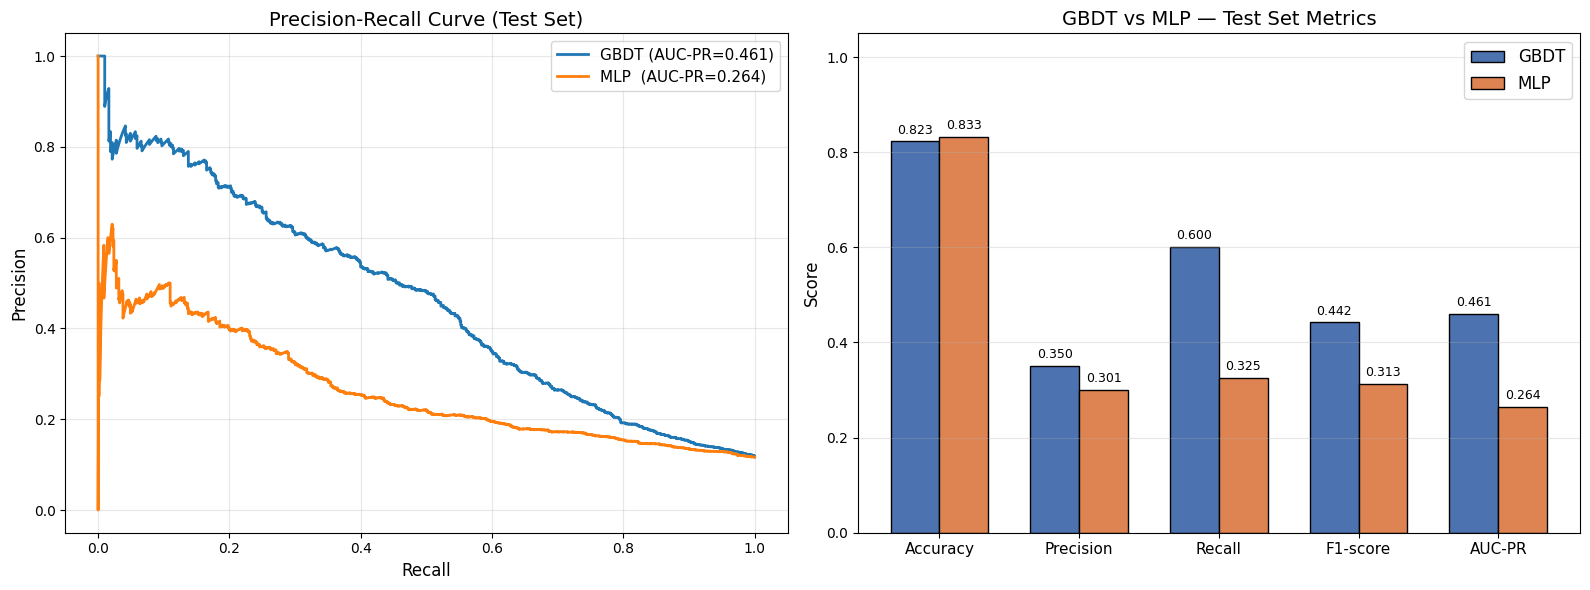

In [163]:
# --- 4.2 Comparison Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Precision-Recall Curves
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_test_prob_xgb)
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test, y_test_prob_mlp)

axes[0].plot(rec_xgb, prec_xgb, linewidth=2, label=f"GBDT (AUC-PR={xgb_metrics['AUC-PR']:.3f})")
axes[0].plot(rec_mlp, prec_mlp, linewidth=2, label=f"MLP  (AUC-PR={mlp_metrics['AUC-PR']:.3f})")
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve (Test Set)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2) Side-by-side metric bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-PR']
x = np.arange(len(metrics_to_plot))
width = 0.35
xgb_vals = [xgb_metrics[m] for m in metrics_to_plot]
mlp_vals = [mlp_metrics[m] for m in metrics_to_plot]

bars1 = axes[1].bar(x - width/2, xgb_vals, width, label='GBDT', color='#4C72B0', edgecolor='black')
bars2 = axes[1].bar(x + width/2, mlp_vals, width, label='MLP', color='#DD8452', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_to_plot, fontsize=11)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('GBDT vs MLP — Test Set Metrics', fontsize=14)
axes[1].legend(fontsize=12)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_comparison.png', dpi=150, bbox_inches='tight')
plt.show()